# 🏗️ 03 — Model 1: Baseline CNN

**Purpose:** Establish the lower bound. No regularization — intentional.

**Architecture:** 4 conv blocks → Global Average Pooling → Linear.

In [1]:
from pathlib import Path
from collections import defaultdict
import random
import json

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

CLASSES = ['plastic', 'paper_cardboard', 'metal', 'glass', 'organic', 'e_waste']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42

PROJECT_ROOT = Path(r'C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification')
PROC_DIR = PROJECT_ROOT / 'notebooks' / 'data' / 'processed'
CKPT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False

class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        for cls in CLASSES:
            cls_dir = self.root / cls
            if cls_dir.exists():
                for img_path in sorted(cls_dir.glob('*.jpg')):
                    self.samples.append((img_path, CLASS_TO_IDX[cls]))
        self.targets = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        counts = defaultdict(int)
        for _, label in self.samples:
            counts[IDX_TO_CLASS[label]] += 1
        return dict(counts)

def get_dataloaders(proc_dir=PROC_DIR, train_tfm=None, val_tfm=None, batch_size=BATCH_SIZE):
    train_ds = WasteDataset(Path(proc_dir) / 'train', train_tfm)
    val_ds = WasteDataset(Path(proc_dir) / 'val', val_tfm)
    test_ds = WasteDataset(Path(proc_dir) / 'test', val_tfm)
    if len(train_ds) == 0:
        raise ValueError(f'No training images found in {Path(proc_dir) / "train"}')

    counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES)
    weights = 1.0 / (counts[train_ds.targets] + 1e-6)
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, **kw)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kw)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kw)
    print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    return train_loader, val_loader, test_loader

class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def train_model(model, model_name, train_loader, val_loader, num_epochs=30, lr=1e-3, weight_decay=1e-4, scheduler_type='cosine', label_smoothing=0.1, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif scheduler_type == 'onecycle':
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    early_stop = EarlyStopping(patience=7)
    best_val_acc = 0.0
    history = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}', flush=True)
    print(f'Model : {model_name}', flush=True)
    print(f'Params: {trainable:,} | Device: {device} | Batch size: {train_loader.batch_size}', flush=True)
    print(f'{"="*60}', flush=True)

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for batch_idx, (imgs, labels) in enumerate(train_loader, start=1):
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loaded', flush=True)
            imgs = imgs.to(device, non_blocking=False)
            labels = labels.to(device, non_blocking=False)
            optimizer.zero_grad(set_to_none=True)
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            if scheduler_type == 'onecycle':
                scheduler.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loss {loss.item():.4f}', flush=True)

        t_loss = run_loss / total
        t_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=False)
                labels = labels.to(device, non_blocking=False)
                out = model(imgs)
                loss = criterion(out, labels)
                v_loss += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += imgs.size(0)
        v_loss /= v_total
        v_acc = v_correct / v_total

        if scheduler_type != 'onecycle':
            scheduler.step()
        for key, value in zip(history, [t_loss, v_loss, t_acc, v_acc]):
            history[key].append(value)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            CKPT_DIR.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), CKPT_DIR / f'{model_name}_best.pth')

        print(f'Epoch {epoch:3d}/{num_epochs} | Train {t_loss:.4f}/{t_acc:.3f} | Val {v_loss:.4f}/{v_acc:.3f}', flush=True)

        early_stop(v_loss)
        if early_stop.early_stop:
            print(f'Early stopping at epoch {epoch}', flush=True)
            break

    history['best_val_acc'] = best_val_acc
    print(f'Best val acc: {best_val_acc:.4f}', flush=True)
    return history

def evaluate_model(model, model_name, test_loader, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    ckpt = CKPT_DIR / f'{model_name}_best.pth'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'Loaded checkpoint: {ckpt.name}')
    model.eval().to(device)
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(device))
            probs = torch.softmax(out, 1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    print(f'\n{model_name} - Test Results')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f} Recall: {r:.4f} F1: {f1:.4f}')
    print('\nPer-class report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))
    return dict(model=model_name, accuracy=acc, precision=p, recall=r, f1=f1, confusion_matrix=cm, preds=all_preds, labels=all_labels, probs=all_probs)

def plot_training_curves(history, model_name, save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(epochs, history['val_loss'], 'r-o', ms=3, label='Val')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train')
    ax2.plot(epochs, history['val_acc'], 'r-o', ms=3, label='Val')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(FIGURES_DIR / f'curves_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(cm, model_name, save=True):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save:
        plt.savefig(FIGURES_DIR / f'cm_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

set_seed()
if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is not available in this notebook kernel.')
DEVICE = torch.device('cuda:0')
torch.backends.cudnn.benchmark = True
print(f'Device: {DEVICE} - {torch.cuda.get_device_name(0)}')
print(f'Using data: {PROC_DIR}')

train_loader, val_loader, test_loader = get_dataloaders(
    proc_dir=PROC_DIR,
    train_tfm=train_transforms,
    val_tfm=val_test_transforms,
)

Device: cuda:0 - NVIDIA GeForce RTX 3070 Laptop GPU
Using data: C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\notebooks\data\processed
Train: 1,888 | Val: 401 | Test: 412


In [2]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

model = BaselineCNN().to(DEVICE)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    output = model(dummy)
print(f'Output shape : {output.shape}')
print(f'Model device : {next(model.parameters()).device}')
print(f'Parameters   : {sum(p.numel() for p in model.parameters()):,}')
print(model)

Output shape : torch.Size([2, 6])
Model device : cuda:0
Parameters   : 583,718
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (

In [3]:
history = train_model(
    model, 'baseline_cnn',
    train_loader, val_loader,
    num_epochs=30, lr=1e-3,
    scheduler_type='cosine',
    device=DEVICE
)


Model : baseline_cnn
Params: 583,718 | Device: cuda:0 | Batch size: 32
  Epoch   1/30 | batch   1/59 | loaded
  Epoch   1/30 | batch   1/59 | loss 1.7954
  Epoch   1/30 | batch   2/59 | loaded
  Epoch   1/30 | batch   2/59 | loss 1.7913
  Epoch   1/30 | batch   3/59 | loaded
  Epoch   1/30 | batch   3/59 | loss 1.7885
  Epoch   1/30 | batch   4/59 | loaded
  Epoch   1/30 | batch   4/59 | loss 1.7823
  Epoch   1/30 | batch   5/59 | loaded
  Epoch   1/30 | batch   5/59 | loss 1.7808
  Epoch   1/30 | batch   6/59 | loaded
  Epoch   1/30 | batch   6/59 | loss 1.7719
  Epoch   1/30 | batch   7/59 | loaded
  Epoch   1/30 | batch   7/59 | loss 1.8202
  Epoch   1/30 | batch   8/59 | loaded
  Epoch   1/30 | batch   8/59 | loss 1.7860
  Epoch   1/30 | batch   9/59 | loaded
  Epoch   1/30 | batch   9/59 | loss 1.7689
  Epoch   1/30 | batch  10/59 | loaded
  Epoch   1/30 | batch  10/59 | loss 1.7745
  Epoch   1/30 | batch  11/59 | loaded
  Epoch   1/30 | batch  11/59 | loss 1.7889
  Epoch   1/30 

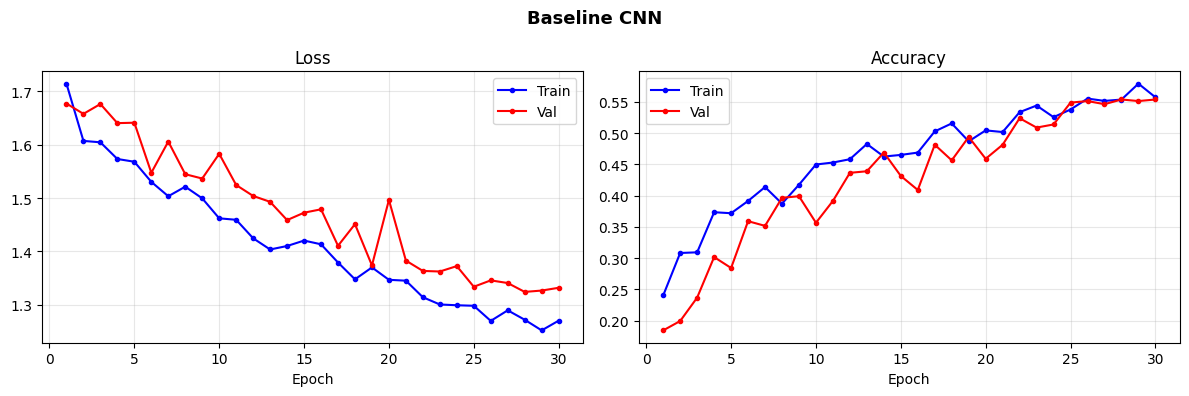

In [4]:
plot_training_curves(history, 'Baseline CNN')

C:\Users\msfir\AppData\Local\Temp\ipykernel_33592\873285163.py:216: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Loaded checkpoint: baseline_cnn_best.pth

baseline_cnn - Test Results
Accuracy : 0.5024
Precision: 0.5153 Recall: 0.5024 F1: 0.4986

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.53      0.56      0.54        66
paper_cardboard       0.64      0.56      0.60       136
          metal       0.46      0.26      0.34        72
          glass       0.25      0.31      0.28        71
        organic       0.45      0.93      0.60        14
        e_waste       0.62      0.75      0.68        53

       accuracy                           0.50       412
      macro avg       0.49      0.56      0.51       412
   weighted avg       0.52      0.50      0.50       412



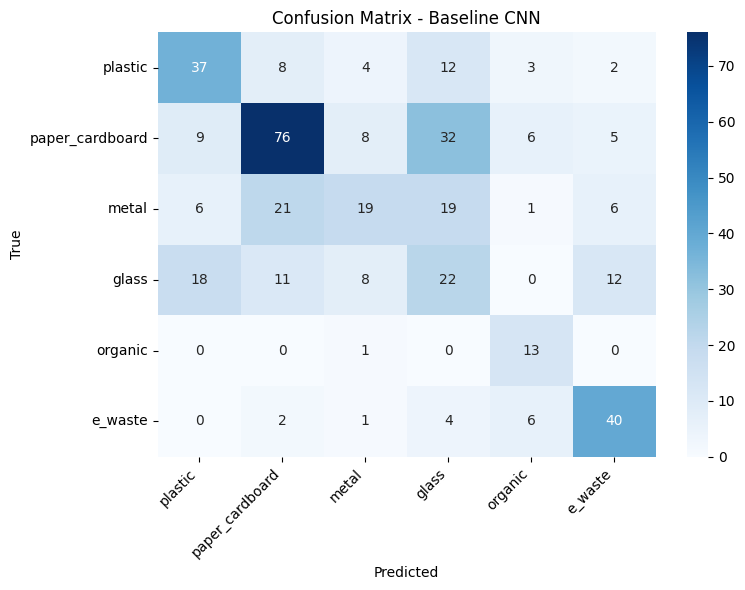

In [5]:
results = evaluate_model(model, 'baseline_cnn', test_loader, device=DEVICE)
plot_confusion_matrix(results['confusion_matrix'], 'Baseline CNN')

In [6]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / 'baseline_cnn_results.json', 'w') as f:
    json.dump({k: v for k, v in results.items()
               if k not in ('confusion_matrix', 'preds', 'labels', 'probs')}, f, indent=2)
print('Results saved.')

Results saved.
